# ASL Object Detector — YOLOv8n (Comparison Notebook)
## yolo26n trained on ASL Letters v6 dataset (YOLO26 format)

This notebook mirrors `train.ipynb` but uses **YOLOv8 nano** (`yolo26n.pt`) via Ultralytics for direct comparison.  
Uses the pre-downloaded `yolo26n.pt` already in this directory — no download needed.

Dataset path: `../data_yolo/`  
Classes: 26 (A–Z, 0-indexed)


## 1. Install Dependencies

In [9]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'ultralytics', '-q'], check=True)
print('ultralytics installed.')

ultralytics installed.


## 2. Verify Dataset Structure

In [10]:
import os
from pathlib import Path

# Notebook runs from train/, so data_yolo is one level up
DATA_ROOT = Path('..') / 'data_yolo'

for split in ['train', 'valid', 'test']:
    imgs = list((DATA_ROOT / split / 'images').glob('*.jpg'))
    lbls = list((DATA_ROOT / split / 'labels').glob('*.txt'))
    print(f'{split:6s}: {len(imgs):4d} images, {len(lbls):4d} labels')

train :  504 images,  504 labels
valid :  144 images,  144 labels
test  :   72 images,   72 labels


## 3. Create data.yaml with Absolute Paths

YOLOv8 requires absolute paths or paths relative to the yaml file location.  
We write a fresh yaml next to the data so paths resolve correctly.

In [11]:
import yaml

data_root_abs = DATA_ROOT.resolve()

data_cfg = {
    'path': str(data_root_abs),
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc': 26,
    'names': [chr(ord('A') + i) for i in range(26)]
}

yaml_path = data_root_abs / 'data_abs.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False, sort_keys=False)

print(f'Wrote: {yaml_path}')
print(f'  train : {data_root_abs / data_cfg["train"]}')
print(f'  val   : {data_root_abs / data_cfg["val"]}')
print(f'  test  : {data_root_abs / data_cfg["test"]}')

Wrote: F:\Documents\lab_mid_ai331\data_yolo\data_abs.yaml
  train : F:\Documents\lab_mid_ai331\data_yolo\train\images
  val   : F:\Documents\lab_mid_ai331\data_yolo\valid\images
  test  : F:\Documents\lab_mid_ai331\data_yolo\test\images


## 4. Visualise Sample Annotations

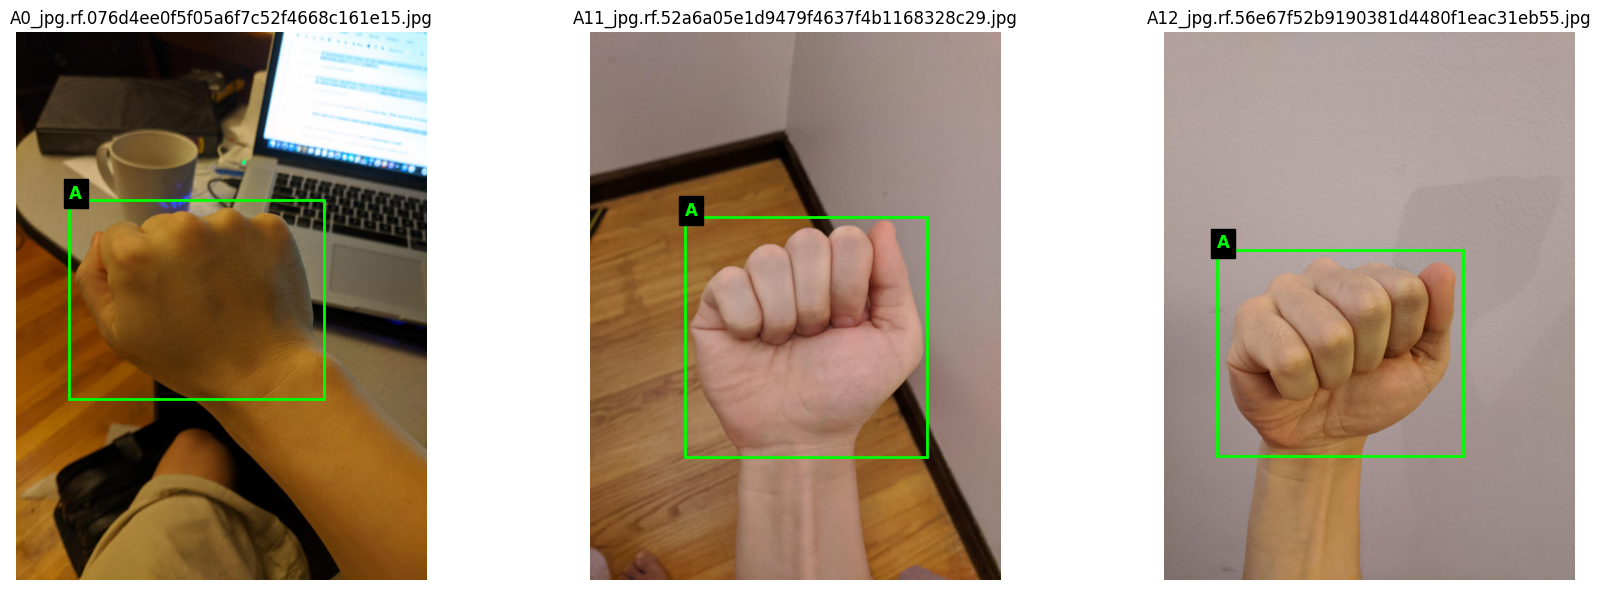

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import random

CLASSES = [chr(ord('A') + i) for i in range(26)]

img_files = list((DATA_ROOT / 'train' / 'images').glob('*.jpg'))[:3]

fig, axes = plt.subplots(1, len(img_files), figsize=(18, 6))
for ax, img_path in zip(axes, img_files):
    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)

    lbl_path = img_path.parent.parent / 'labels' / img_path.with_suffix('.txt').name
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            parts = list(map(float, line.split()))
            cls_id = int(parts[0])
            cx, cy, bw, bh = parts[1], parts[2], parts[3], parts[4]
            x1 = (cx - bw / 2) * w
            y1 = (cy - bh / 2) * h
            rw, rh = bw * w, bh * h
            rect = mpatches.Rectangle((x1, y1), rw, rh, linewidth=2,
                                       edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, CLASSES[cls_id], color='lime', fontsize=12,
                    fontweight='bold', backgroundcolor='black')
    ax.set_title(img_path.name)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Train yolo26n

Uses **`yolo26n.pt`** already in this folder — no internet needed.  
Key settings:
- `imgsz=640` — matches Faster R-CNN resize  
- `epochs=50` — YOLO converges faster  
- `batch=4` — safe for most GPUs; increase to 8 if you have >8 GB VRAM  
- `mosaic=0.0` — **disabled**: mosaic internally creates 4× larger batches which causes `cudaErrorIllegalAddress` on constrained GPUs  
- `scale=0.5` — same scale jitter added to `train.ipynb`


In [13]:
import os
from pathlib import Path
from ultralytics import YOLO
import torch

device = 0 if torch.cuda.is_available() else 'cpu'
print(f'Training on: {"GPU" if device == 0 else "CPU"}')
if device == 0:
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Pin project to the notebook's own directory so weights land here, not in the venv
TRAIN_DIR = Path(os.getcwd()).resolve()
PROJECT_DIR = TRAIN_DIR / 'yolo_runs'

model = YOLO('yolo26n.pt')

results = model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=4,
    device=device,
    project=str(PROJECT_DIR),   # absolute path — prevents Ultralytics saving to venv
    name='asl_yolo26n',
    exist_ok=True,
    hsv_h=0.015,
    hsv_s=0.4,
    hsv_v=0.4,
    scale=0.5,
    fliplr=0.5,
    degrees=10.0,
    translate=0.1,
    mosaic=0.0,
    patience=15,
    save_period=10,
    verbose=True,
)
print(f'\nWeights saved under: {PROJECT_DIR / "asl_yolo26n" / "weights"}')


Training on: GPU
VRAM: 8.6 GB
Ultralytics 8.4.21  Python-3.13.12 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=F:\Documents\lab_mid_ai331\data_yolo\data_abs.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=asl_yolo26n, nbs=64, nms=False, opset=None, optimize=F

## 6. Evaluate on Validation & Test Sets (mAP@50)

In [14]:
import glob as _glob

# Known Ultralytics fallback path from this run
FALLBACK = r'F:\Documents\vgg16\runs\detect\yolo_runs\asl_yolo26n'

# Search order: local first, then the venv fallback
search_patterns = [
    str(PROJECT_DIR / 'asl_yolo26n*' / 'weights' / 'best.pt'),
    FALLBACK + r'\weights\best.pt',
    str(PROJECT_DIR / 'asl_yolo26n*' / 'weights' / 'last.pt'),
    FALLBACK + r'\weights\last.pt',
]

best_weights = None
for pattern in search_patterns:
    hits = sorted(_glob.glob(pattern))
    if hits:
        best_weights = hits[-1]
        break

if best_weights is None:
    raise FileNotFoundError('No weights found. Check the training output path above.')

print(f'Loading weights: {best_weights}')
eval_model = YOLO(best_weights)

print('=== Validation Set ===')
val_metrics = eval_model.val(data=str(yaml_path), split='val', imgsz=640, device=device, verbose=False)
print(f'mAP@50   : {val_metrics.box.map50:.4f}')
print(f'mAP@50-95: {val_metrics.box.map:.4f}')
print('\nPer-class AP@50:')
for cls_name, ap in zip(val_metrics.names.values(), val_metrics.box.ap50):
    print(f'  {cls_name}: {ap:.4f}')

print('\n' + '='*50)
print('=== Test Set ===')
test_metrics = eval_model.val(data=str(yaml_path), split='test', imgsz=640, device=device, verbose=False)
print(f'mAP@50   : {test_metrics.box.map50:.4f}')
print(f'mAP@50-95: {test_metrics.box.map:.4f}')
print('\nPer-class AP@50:')
for cls_name, ap in zip(test_metrics.names.values(), test_metrics.box.ap50):
    print(f'  {cls_name}: {ap:.4f}')


Loading weights: F:\Documents\lab_mid_ai331\train\yolo_runs\asl_yolo26n\weights\best.pt
=== Validation Set ===
Ultralytics 8.4.21  Python-3.13.12 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
YOLO26n summary (fused): 122 layers, 2,379,906 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2470.9339.9 MB/s, size: 210.1 KB)
val: Scanning F:\Documents\lab_mid_ai331\data_yolo\valid\labels.cache... 144 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 144/144 54.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 5.5it/s 1.6s0.1ss
                   all        144        144      0.766      0.693       0.84      0.777
Speed: 1.5ms preprocess, 2.5ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to F:\Documents\vgg16\runs\detect\val
mAP@50   : 0.8400
mAP@50-95: 0.7769

Per-class AP@50:
  A: 0.7767
  B: 0.8112
  C: 0.9950
  D: 0.9721
  E: 0.7629
  F: 0.88

## 7. Side-by-Side Comparison: Faster R-CNN vs yolo26n


In [15]:
# Faster R-CNN results from train.ipynb
rcnn_val  = 0.8924
rcnn_test = 0.8423

yolo_val  = val_metrics.box.map50
yolo_test = test_metrics.box.map50

print('Model              | Val mAP@50 | Test mAP@50')
print('-------------------|------------|------------')
print(f'Faster R-CNN       |  {rcnn_val:.4f}   |  {rcnn_test:.4f}')
print(f'yolo26n            |  {yolo_val:.4f}   |  {yolo_test:.4f}')


Model              | Val mAP@50 | Test mAP@50
-------------------|------------|------------
Faster R-CNN       |  0.8924   |  0.8423
yolo26n            |  0.8400   |  0.8201


## 8. Visualise YOLOv8 Predictions on Test Images

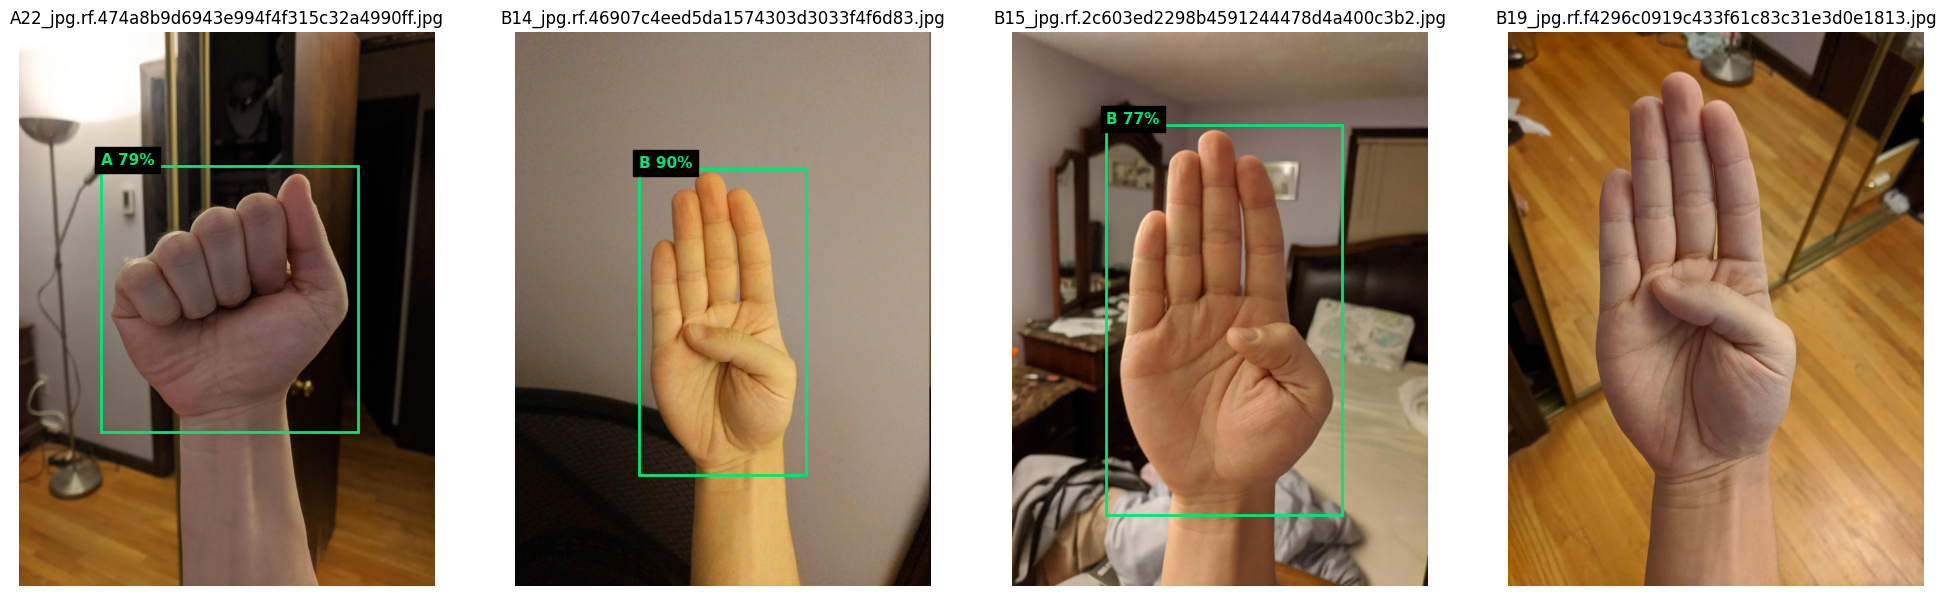

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image as PILImage

test_imgs = list((DATA_ROOT / 'test' / 'images').glob('*.jpg'))[:4]

results_list = eval_model.predict(source=[str(p) for p in test_imgs],
                                  imgsz=640, conf=0.3, device=device, verbose=False)

fig, axes = plt.subplots(1, len(test_imgs), figsize=(20, 6))
for ax, img_path, r in zip(axes, test_imgs, results_list):
    img = PILImage.open(img_path).convert('RGB')
    ax.imshow(img)
    w, h = img.size
    sx, sy = w / r.orig_shape[1], h / r.orig_shape[0]
    for box in r.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls_id = int(box.cls[0])
        conf   = float(box.conf[0])
        rect = mpatches.Rectangle((x1 * sx, y1 * sy), (x2 - x1) * sx, (y2 - y1) * sy,
                                   linewidth=2, edgecolor='#00e676', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1 * sx, y1 * sy - 5,
                f'{CLASSES[cls_id]} {conf:.0%}',
                color='#00e676', fontsize=11, fontweight='bold', backgroundcolor='black')
    ax.set_title(img_path.name)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Export Best Weights Path

In [17]:
import shutil, os

dst = 'yolo26n_best.pt'
shutil.copy(best_weights, dst)
size_mb = os.path.getsize(dst) / 1e6
print(f'Saved: {dst}  ({size_mb:.1f} MB)')
print(f'Source: {best_weights}')
print(f'To load: YOLO("train/yolo26n_best.pt")')


Saved: yolo26n_best.pt  (5.4 MB)
Source: F:\Documents\lab_mid_ai331\train\yolo_runs\asl_yolo26n\weights\best.pt
To load: YOLO("train/yolo26n_best.pt")
